In [10]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

from src.urn import PolyaUrn

import numpy as np
import matplotlib.pyplot as plt

# Domination permanente dans les urnes de Pólya généralisées

On considère l’événement de trajectoire

$
A = \{B_n > W_n,\ \forall n \ge 0\}
$

Cet événement est une propriété de la trajectoire stochastique $(B_n, W_n)$.
Il exige que les boules noires restent strictement au-dessus des boules blanches à chaque étape observée.

Le notebook commence par une trajectoire représentative, puis passe à une estimation de la probabilité empirique de A par simulations de Monte Carlo.

### Illustration de trajectoire

La première expérience produit une réalisation à partir de l’état initial $(B_0,W_0)=(10,5)$ avec des renforts $(2,1)$.
Nous examinons cette trajectoire afin de comprendre comment les fluctuations initiales affectent l’événement de domination permanente.

In [11]:
urn = PolyaUrn(
    balls={"black": 10, "white": 5},
    reinforcements={"black": 2, "white": 1}
)

urn.simulate(100)

### Vérification de la domination permanente sur une trajectoire

La méthode `always_black_leading()` vérifie si la trajectoire enregistrée satisfait l’événement A à chaque étape simulée.
Il s’agit d’un test sur une trajectoire individuelle, et non d’une statistique de population.

In [12]:
urn.always_black_leading()

True

### Extraction de la trajectoire

Nous extrayons maintenant la suite des effectifs de boules noires et blanches à partir de l’historique simulé.
Les courbes obtenues représentent la trajectoire stochastique de l’urne et permettent de voir si le blanc réduit l’écart.

In [13]:
black_counts = [
    state["black"]
    for state in urn.history
]

white_counts = [
    state["white"]
    for state in urn.history
]

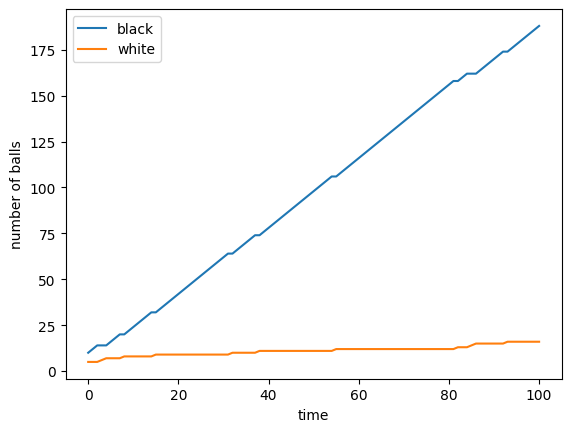

In [14]:
plt.plot(black_counts, label="black")
plt.plot(white_counts, label="white")

plt.xlabel("time")
plt.ylabel("number of balls")

plt.legend()

plt.show()

### Interprétation de la trajectoire

La trajectoire ci-dessus illustre un cas de domination soutenue des boules noires sur l’horizon simulé.

Les paramètres choisis favorisent fortement le noir :
- par l’avantage initial de composition ;
- par le mécanisme de renforcement asymétrique.

Après quelques fluctuations initiales limitées, l’écart entre les deux couleurs tend à s’amplifier progressivement sous l’effet du renforcement.

Cette trajectoire suggère qu’un renforcement asymétrique peut renforcer la domination d’une couleur sur l’horizon étudié.

Cependant, une seule réalisation ne permet pas d’évaluer précisément la probabilité de l’événement

$
A = \{B_n > W_n,\ \forall n \geq 0\}.
$

Cela motive l’utilisation de simulations de Monte Carlo afin d’estimer empiriquement la fréquence de domination permanente.

### Estimation par simulations de Monte Carlo

Nous approchons la probabilité de A en générant des trajectoires indépendantes avec les mêmes paramètres d’urne et en comptant la proportion de cas où le noir reste strictement dominant pendant 100 étapes.
Cette fréquence empirique est une estimation, et elle reste sensible au nombre de simulations ainsi qu’à l’horizon fini choisi.

In [15]:
successes = 0

n_simulations = 100

In [16]:
for _ in range(n_simulations):

    urn = PolyaUrn(
        balls={"black": 10, "white": 5},
        reinforcements={"black": 2, "white": 1}
    )

    urn.simulate(100)

    if urn.always_black_leading():
        successes += 1

In [17]:
estimated_probability = successes / n_simulations

estimated_probability

0.99

## Conclusion

Les simulations de Monte Carlo réalisées dans ce notebook suggèrent que, pour le régime étudié et l’horizon de simulation, la domination des boules noires est très probable.

Avec les paramètres :
- \(B_0 = 10\),
- \(W_0 = 5\),
- \(m_b = 2\),
- \(m_w = 1\),

la fréquence empirique obtenue est proche de \(0.99\) sur un horizon de \(100\) étapes.

Ce résultat suggère qu’un avantage initial combiné à un renforcement asymétrique favorable stabilise fortement la domination des boules noires sur l’horizon étudié.

Les trajectoires simulées montrent également l’importance des premiers tirages : les fluctuations initiales peuvent modifier significativement la dynamique future du système.

Cependant, cette estimation reste empirique :
- elle dépend du nombre de simulations réalisées ;
- elle dépend également de l’horizon temporel choisi.

Une étude plus approfondie nécessiterait :
- l’analyse systématique des paramètres ;
- l’augmentation du nombre de simulations ;
- et une approche théorique permettant d’étudier rigoureusement la probabilité de domination permanente.